In [1]:
pip install osfclient

Note: you may need to restart the kernel to use updated packages.


In [2]:
!osf -p f5rn6 clone THINGS-behavior

0files [00:00, ?files/s]
  0%|                                            | 0.00/101M [00:00<?, ?bytes/s]
  0%|                                    | 49.2k/101M [00:00<03:32, 476kbytes/s]
  0%|                                     | 147k/101M [00:00<02:19, 727kbytes/s]
  0%|▏                                   | 426k/101M [00:00<01:01, 1.63Mbytes/s]
  1%|▍                                  | 1.31M/101M [00:00<00:22, 4.39Mbytes/s]
  4%|█▎                                 | 3.92M/101M [00:00<00:08, 12.0Mbytes/s]
  6%|██▏                                | 6.34M/101M [00:00<00:05, 16.1Mbytes/s]
  9%|███                                | 8.85M/101M [00:00<00:05, 18.0Mbytes/s]
 12%|████                               | 11.6M/101M [00:00<00:04, 20.4Mbytes/s]
 14%|████▊                              | 13.8M/101M [00:00<00:04, 20.0Mbytes/s]
 16%|█████▍                             | 15.8M/101M [00:01<00:04, 18.1Mbytes/s]
 17%|██████                             | 17.6M/101M [00:01<00:05, 15.5Mbytes/s]
 19

In [3]:
!pip install torch torchvision torchaudio --quiet
!pip install pandas numpy scikit-learn tqdm matplotlib seaborn --quiet

In [4]:
import zipfile
extract_to = r'/Users/natmacbookpro/Desktop/COGS 202/cogs202_project'

with zipfile.ZipFile("/Users/natmacbookpro/Desktop/COGS 202/cogs202_project/THINGS-behavior/osfstorage/full_triplet_dataset.zip") as z:
    z.extractall(extract_to)

# Loading the Human Similarity Judgement Embeddings (SPOSE) & Triplets Dataset

In [5]:
import os
import pandas as pd

base_dir = '/Users/natmacbookpro/Desktop/COGS 202/cogs202_project/THINGS-behavior/osfstorage'

# SPoSE embedding (66-dimensional, sorted by variance explained) = human similarity embedding derived from the triplet data - 1854 rows (objects), 66 columns (dimensions)
emb_path = f"{base_dir}/data/spose_embedding_66d_sorted.txt"
spose_emb = pd.read_csv(emb_path, sep=r'\s+', header=None).values
print("SPoSE embedding shape:", spose_emb.shape)

# Triplets (main data) for training model - 1.7 million rows, 3 columns (image1, image2, image3)
triplets_path = f"{base_dir}/data/triplet_dataset/triplets_large_final_correctednc_correctedorder.csv"
triplets = pd.read_csv(triplets_path, sep='\t')
print("Full triplets shape:", triplets.shape)
print("Columns:", triplets.columns.tolist())

#  Using a subsample for faster computation
triplets_sample = triplets.sample(n=50000, random_state=42) if len(triplets) > 50000 else triplets
print("Using", len(triplets_sample), "triplets for analysis")

SPoSE embedding shape: (1854, 66)
Full triplets shape: (4699160, 14)
Columns: ['image1', 'image2', 'image3', 'choice', 'RT', 'noise_ceiling', 'subject_id', 'HIT_nr', 'trial_nr', 'age', 'gender', 'date', 'time', 'dataset']
Using 50000 triplets for analysis


In [6]:
triplets.head()

,image1,image2,image3,choice,RT,noise_ceiling,subject_id,HIT_nr,trial_nr,age,gender,date,time,dataset
0,1245,1050,494,3,14457,0,BMWLG5ZY79VLA,1,1,NaN,other,2018-02-05,09:31:16,1
1,888,1788,1250,3,5043,0,BMWLG5ZY79VLA,1,2,NaN,other,2018-02-05,09:31:16,1
2,1256,734,946,2,6605,0,BMWLG5ZY79VLA,1,3,NaN,other,2018-02-05,09:31:16,1
3,1069,1037,953,1,6177,0,BMWLG5ZY79VLA,1,4,NaN,other,2018-02-05,09:31:16,1
4,1693,803,963,3,2327,0,BMWLG5ZY79VLA,1,5,NaN,other,2018-02-05,09:31:16,1


# Loading the Images

In [7]:
# Paths
image_base_dir = "/Users/natmacbookpro/Desktop/reference_images"
unique_id_path = "THINGS-behavior/osfstorage/variables/unique_id.txt"

# Load the correct order from unique_id.txt
with open(unique_id_path, 'r') as f:
    unique_ids = [line.strip() for line in f.readlines()]

print(f"Loaded {len(unique_ids)} concepts from unique_id.txt")

# Build image_paths using the correct order
image_paths = []

for concept in unique_ids:
    image_name = f"{concept}.jpg"                    # as you said the files are named
    full_path = os.path.join(image_base_dir, image_name)
    
    if os.path.exists(full_path):
        image_paths.append(full_path)
    else:
        image_paths.append(None)

# Filter valid ones
image_paths = [p for p in image_paths if p is not None]

print(f"\nSuccessfully mapped {len(image_paths)} / {len(unique_ids)} images")

Loaded 1854 concepts from unique_id.txt



Successfully mapped 1854 / 1854 images


## Image Preprocessing

In [8]:
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np
from tqdm import tqdm 

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_img(path):
    img = Image.open(path).convert('RGB')
    return preprocess(img).unsqueeze(0)



## Extracting Layer Features/Embeddings for Resnet-50 and Alexnet on Things Images

In [9]:
def extract_alexnet_layer_features(image_paths):
    '''Extract features from every layer of AlexNet for a list of image paths. 
    Returns a dictionary mapping layer names to feature arrays.'''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.alexnet(pretrained=True).eval().to(device)
    
    # Features = convolutional layers, Classifier = fully connected layers
    features = list(model.features.children())
    classifier = list(model.classifier.children())
    
    # We will extract features after each layer in features, after avgpool, after flattening, and after each layer in classifier
    all_layers = features + ["avgpool", "flatten"] + classifier
    layer_names = [f'layer_{i}' for i in range(len(all_layers))]
    features_dict = {name: [] for name in layer_names}
    
    with torch.no_grad():
        for path in tqdm(image_paths, desc="AlexNet"):
            x = load_img(path).to(device)
            
            # Pass through Features (Convolutional layers)
            current_idx = 0
            for layer in features:
                x = layer(x)
                # Global average pooling for convolutional layers to get a fixed-size feature vector
                feat = x.mean(dim=[2, 3]).squeeze().cpu().numpy() if x.dim() > 2 else x.squeeze().cpu().numpy()
                features_dict[layer_names[current_idx]].append(feat)
                current_idx += 1
            
            # Avgpool and flatten before classifier to get the correct feature vector for the fully connected layers
            x = model.avgpool(x)
            features_dict[layer_names[current_idx]].append(x.mean(dim=[2, 3]).squeeze().cpu().numpy())
            current_idx += 1
            
            x = torch.flatten(x, 1) # Flatten to [Batch, 9216]
            features_dict[layer_names[current_idx]].append(x.squeeze().cpu().numpy())
            current_idx += 1
            
            # Pass through Classifier (fully connected layers)
            for layer in classifier:
                x = layer(x)
                feat = x.squeeze().cpu().numpy()
                features_dict[layer_names[current_idx]].append(feat)
                current_idx += 1
    
    # Stack + L2 normalize
    for name in features_dict:
        features_dict[name] = np.stack(features_dict[name])
        # Add a small epsilon to avoid division by zero
        norm = np.linalg.norm(features_dict[name], axis=1, keepdims=True)
        features_dict[name] = features_dict[name] / (norm + 1e-10)
    
    return features_dict

# resnet50 has residual connections, so need to extract features after residual blocks instead of after every layer
def extract_resnet50_layer_features(image_paths): 
    '''Extract features from every layer of ResNet50 for a list of image paths.'''  
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.resnet50(pretrained=True).eval().to(device)
    
    children = list(model.children())
    
    layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']   # avgpool = homework's layer
    features_dict = {name: [] for name in layer_names}
    
    with torch.no_grad():
        for path in tqdm(image_paths, desc="ResNet50"):
            x = load_img(path).to(device)
            
            x = children[0](x)  # conv1
            x = children[1](x)  # bn1
            x = children[2](x)  # relu
            x = children[3](x)  # maxpool
            
            # Residual layers
            x = children[4](x)  # layer1
            features_dict['layer1'].append(x.mean([2,3]).squeeze().cpu().numpy())
            
            x = children[5](x)  # layer2
            features_dict['layer2'].append(x.mean([2,3]).squeeze().cpu().numpy())
            
            x = children[6](x)  # layer3
            features_dict['layer3'].append(x.mean([2,3]).squeeze().cpu().numpy())
            
            x = children[7](x)  # layer4
            features_dict['layer4'].append(x.mean([2,3]).squeeze().cpu().numpy())
            

            # Avgpool is already global average pooling, so take the output and flatten it  
            x = children[8](x)  # avgpool
            features_dict['avgpool'].append(x.squeeze().cpu().numpy())
    
    # Stack + L2 normalize
    for name in features_dict:
        features_dict[name] = np.stack(features_dict[name])
        features_dict[name] = features_dict[name] / np.linalg.norm(features_dict[name], axis=1, keepdims=True)
    
    return features_dict

In [10]:
# Extract features for all reference images and print matrix shapes
print(f"Extracting features for {len(image_paths)} images...")

alex_features = extract_alexnet_layer_features(image_paths)
resnet_features = extract_resnet50_layer_features(image_paths)

print("Done!")
for name, f in alex_features.items():
    print(f"AlexNet {name:12} → {f.shape}")
    
for name, f in resnet_features.items():
    print(f"ResNet50 {name:12} → {f.shape}")

Extracting features for 1854 images...


/Users/natmacbookpro/opt/anaconda3/envs/replay/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/natmacbookpro/opt/anaconda3/envs/replay/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
AlexNet: 100%|██████████| 1854/1854 [02:15<00:00, 13.71it/s]
/Users/natmacbookpro/opt/anaconda3/envs/replay/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The 

Done!
AlexNet layer_0      → (1854, 64)
AlexNet layer_1      → (1854, 64)
AlexNet layer_2      → (1854, 64)
AlexNet layer_3      → (1854, 192)
AlexNet layer_4      → (1854, 192)
AlexNet layer_5      → (1854, 192)
AlexNet layer_6      → (1854, 384)
AlexNet layer_7      → (1854, 384)
AlexNet layer_8      → (1854, 256)
AlexNet layer_9      → (1854, 256)
AlexNet layer_10     → (1854, 256)
AlexNet layer_11     → (1854, 256)
AlexNet layer_12     → (1854, 256)
AlexNet layer_13     → (1854, 256)
AlexNet layer_14     → (1854, 9216)
AlexNet layer_15     → (1854, 9216)
AlexNet layer_16     → (1854, 4096)
AlexNet layer_17     → (1854, 4096)
AlexNet layer_18     → (1854, 4096)
AlexNet layer_19     → (1854, 4096)
AlexNet layer_20     → (1854, 4096)
AlexNet layer_21     → (1854, 1000)
ResNet50 layer1       → (1854, 256)
ResNet50 layer2       → (1854, 512)
ResNet50 layer3       → (1854, 1024)
ResNet50 layer4       → (1854, 2048)
ResNet50 avgpool      → (1854, 2048)


## Odd-One-Out Task - Cosine Similarity of Layer Features

In [11]:
def odd_one_out_accuracy(features, triplets_sample):
    '''Evaluate the odd-one-out accuracy of a model's features on a sample of 
    the triplets dataset.'''
    # Set up counters
    correct = 0
    total = len(triplets_sample)
    
    # Loop through each triplet and compute model's choice
    for _, row in tqdm(triplets_sample.iterrows(), total=total, desc="Evaluating"):
        i1 = int(row['image1']) - 1 # image indices are 1-based in the dataset, so subtract 1 for 0-based indexing
        i2 = int(row['image2']) - 1
        i3 = int(row['image3']) - 1
        human_choice = int(row['choice']) - 1 # human choice on OOO
        
        # Get features for the three images in the triplet
        f1 = features[i1]
        f2 = features[i2]
        f3 = features[i3]
        
        # Compute cosine similarities
        sim12 = np.dot(f1, f2) / (np.linalg.norm(f1) * np.linalg.norm(f2) + 1e-8)
        sim13 = np.dot(f1, f3) / (np.linalg.norm(f1) * np.linalg.norm(f3) + 1e-8)
        sim23 = np.dot(f2, f3) / (np.linalg.norm(f2) * np.linalg.norm(f3) + 1e-8)
        
        # The odd one out is the pair with the lowest average similarity between the two images
        avg1 = (sim12 + sim13) / 2
        avg2 = (sim12 + sim23) / 2
        avg3 = (sim13 + sim23) / 2
        
        # Model's choice is the one with the lowest average similarity
        model_choice = np.argmin([avg1, avg2, avg3])
        
        # Compare model's choice to human choice, if the same, then model is correct
        if model_choice == human_choice:
            correct += 1
    
    # Compute accuracy as percentage
    accuracy = (correct / total) * 100
    return accuracy

## Running the Odd-One-Out Task on Resnet-50 and Alexnet Feature Embeddings, Layer-wise

In [12]:
# Run odd-one-out comparison for each layer of AlexNet and ResNet50
print(f"Running odd-one-out comparison on {len(triplets_sample)} triplets\n")

results = []

# AlexNet Layers
print("AlexNet Layers")
for layer_name, features in alex_features.items():
    acc = odd_one_out_accuracy(features, triplets_sample)
    results.append({'Model': 'AlexNet', 'Layer': layer_name, 'Accuracy %': round(acc, 2)})
    print(f"AlexNet {layer_name:12} → {acc:.2f}%")

# ResNet50 Layers
print("ResNet50 Layers")
for layer_name, features in resnet_features.items():
    acc = odd_one_out_accuracy(features, triplets_sample)
    results.append({'Model': 'ResNet50', 'Layer': layer_name, 'Accuracy %': round(acc, 2)})
    print(f"ResNet50 {layer_name:12} → {acc:.2f}%")

# Create DataFrame and save results to CSV
df = pd.DataFrame(results)
df.to_csv('odd_one_out_comparison_results.csv', index=False)

Running odd-one-out comparison on 50000 triplets

AlexNet Layers


Evaluating: 100%|██████████| 50000/50000 [00:03<00:00, 14283.55it/s]


AlexNet layer_0      → 37.97%


Evaluating: 100%|██████████| 50000/50000 [00:03<00:00, 14549.32it/s]


AlexNet layer_1      → 38.57%


...

ResNet50 layer3       → 43.64%


Evaluating: 100%|██████████| 50000/50000 [00:03<00:00, 13531.84it/s]


ResNet50 layer4       → 47.25%


Evaluating: 100%|██████████| 50000/50000 [00:03<00:00, 13308.04it/s]

ResNet50 avgpool      → 47.25%


## Accuracy Results of Selecting the Odd-One-Out Image Based on Cosine Similarity of Layer Features

In [13]:
# Print dataframe by sorted accuracy results
print(df.sort_values(by='Accuracy %', ascending=False).to_string(index=False))

   Model    Layer  Accuracy %
 AlexNet layer_21       50.11
ResNet50  avgpool       47.25
ResNet50   layer4       47.25
 AlexNet layer_20       46.85
 AlexNet layer_19       46.85
 AlexNet layer_12       46.37
 AlexNet layer_13       46.37
 AlexNet layer_14       45.99
 AlexNet layer_15       45.99
 AlexNet layer_11       45.90
 AlexNet layer_17       45.26
 AlexNet layer_18       45.26
 AlexNet layer_16       45.26
 AlexNet layer_10       44.97
 AlexNet  layer_9       44.12
 AlexNet  layer_8       43.77
ResNet50   layer3       43.64
 AlexNet  layer_7       41.85
 AlexNet  layer_6       41.31
 AlexNet  layer_4       40.56
ResNet50   layer2       40.07
 AlexNet  layer_5       39.96
ResNet50   layer1       39.18
 AlexNet  layer_1       38.57
 AlexNet  layer_2       38.19
 AlexNet  layer_0       37.97
 AlexNet  layer_3       37.67


## Layer-wise RSA Function

In [14]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

def compute_layer_rsa(features, human_sim_matrix):
    '''Compute the RSA (Representational Similarity Analysis) 
    correlation between model features and human similarity matrix.'''
    # Features shape should be (1854, D)
    S_pred = features @ features.T  # raw inner product similarity
    
    # Extract lower triangle values for correlation
    tril_idx = np.tril_indices_from(human_sim_matrix, k=-1)
    
    human_vals = human_sim_matrix[tril_idx]
    model_vals = S_pred[tril_idx]
    
    # Compute Pearson r of model similarity vs human similarity
    r, p = pearsonr(model_vals, human_vals)
    return r, p

## First get the human similarity judgement matrix from SPOSE embeddings

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
human_sim_matrix = cosine_similarity(spose_emb)

print("Human similarity matrix shape:", human_sim_matrix.shape)

Human similarity matrix shape: (1854, 1854)


## Compute Pearson r between model similarity matrix and human similarity matrix

In [16]:
print("Computing Pearson correlation (RSA) for every layer\n")

results = []

# RSA for AlexNet layers 
print("AlexNet layers:")
for layer_name, feature in alex_features.items():
    r, p = compute_layer_rsa(feature, human_sim_matrix)
    results.append({
        'Model': 'AlexNet',
        'Layer': layer_name,
        'Pearson_r': round(r, 4),
        'p_value': p
    })
    print(f"  {layer_name:12} → r = {r:.4f} (p = {p:.2e})")

# RSA for ResNet50 layers
print("\nResNet50 layers:")
for layer_name, feature in resnet_features.items():
    r, p = compute_layer_rsa(feature, human_sim_matrix)
    results.append({
        'Model': 'ResNet50',
        'Layer': layer_name,
        'Pearson_r': round(r, 4),
        'p_value': p
    })
    print(f"  {layer_name:12} → r = {r:.4f} (p = {p:.2e})")

# Final table sorted by Pearson r
df_pearson = pd.DataFrame(results)
df_sorted = df_pearson.sort_values(by='Pearson_r', ascending=False)

print("\n")
print(df_sorted.to_string(index=False))

# Save to CSV
df_sorted.to_csv('layerwise_rsa_results.csv', index=False)

Computing Pearson correlation (RSA) for every layer

AlexNet layers:
  layer_0      → r = 0.1408 (p = 0.00e+00)
  layer_1      → r = 0.1581 (p = 0.00e+00)
  layer_2      → r = 0.1347 (p = 0.00e+00)
  layer_3      → r = 0.1154 (p = 0.00e+00)
  layer_4      → r = 0.2200 (p = 0.00e+00)
  layer_5      → r = 0.1911 (p = 0.00e+00)
  layer_6      → r = 0.2190 (p = 0.00e+00)
  layer_7      → r = 0.2517 (p = 0.00e+00)
  layer_8      → r = 0.2993 (p = 0.00e+00)
  layer_9      → r = 0.3221 (p = 0.00e+00)
  layer_10     → r = 0.3385 (p = 0.00e+00)
  layer_11     → r = 0.3976 (p = 0.00e+00)
  layer_12     → r = 0.3978 (p = 0.00e+00)
  layer_13     → r = 0.3978 (p = 0.00e+00)
  layer_14     → r = 0.4004 (p = 0.00e+00)
  layer_15     → r = 0.4004 (p = 0.00e+00)
  layer_16     → r = 0.3742 (p = 0.00e+00)
  layer_17     → r = 0.3742 (p = 0.00e+00)
  layer_18     → r = 0.3742 (p = 0.00e+00)
  layer_19     → r = 0.4246 (p = 0.00e+00)
  layer_20     → r = 0.4246 (p = 0.00e+00)
  layer_21     → r = 0.5400 

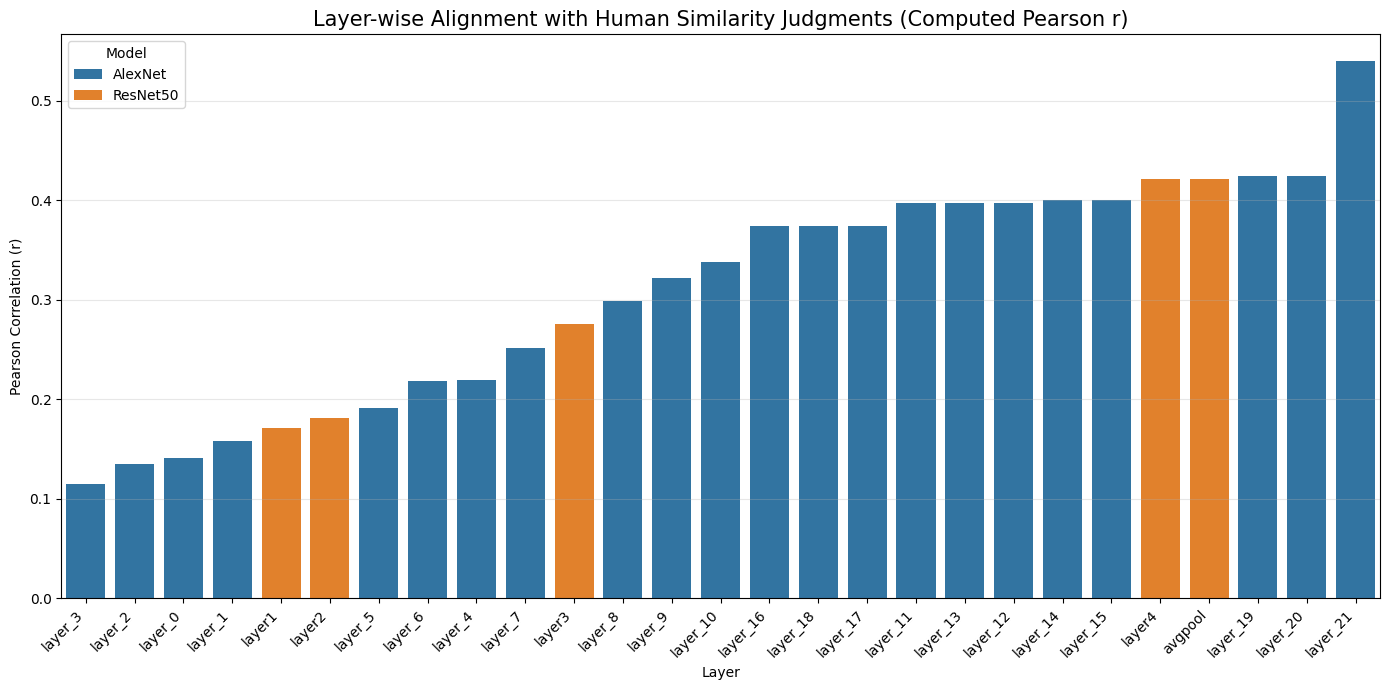

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Plot for Pearson r values by layer and model
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_pearson.sort_values('Pearson_r', ascending=True),
    x='Layer',
    y='Pearson_r',
    hue='Model',
    palette={'AlexNet': '#1f77b4', 'ResNet50': '#ff7f0e'}
)
plt.title('Layer-wise Alignment with Human Similarity Judgments (Computed Pearson r)', fontsize=15)
plt.xlabel('Layer')
plt.ylabel('Pearson Correlation (r)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()